# Nifty 50 — Garman–Klass Yang–Zhang (GKYZ) realized volatility

Daily **OHLC** from **NSE via `nselib`** (`Nifty 50`). Set **`START_DATE`** and **`STOP_DATE`** below (or `STOP_DATE = None` for today). Rolling **GKYZ** (Yang–Zhang) for **7, 22, 30, 60, 90** sessions.

`pip install nselib pandas numpy matplotlib`

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta

from nselib import capital_market

INDEX_NAME = "Nifty 50"
TRADING_DAYS_PER_YEAR = 252
WINDOWS = [7, 22, 30, 60, 90]    # rolling GKYZ windows (sessions)


def parse_date(value: str | date | None) -> date:
    """Accept YYYY-MM-DD, dd-mm-YYYY, or datetime-like strings."""
    if value is None:
        return date.today()
    if isinstance(value, date):
        return value
    s = str(value).strip()
    if len(s) >= 10 and s[4] == "-" and s[7] == "-":
        return pd.to_datetime(s, format="%Y-%m-%d").date()
    return pd.to_datetime(s, dayfirst=True).date()


def to_nselib_date(d: date) -> str:
    return d.strftime("%d-%m-%Y")


def load_nifty_ohlc(from_date: str, to_date: str) -> pd.DataFrame:
    """Fetch Nifty 50 index OHLC from nselib; dates as dd-mm-YYYY."""
    raw = capital_market.index_data(INDEX_NAME, from_date, to_date)
    df = raw.copy()
    df["Date"] = pd.to_datetime(df["TIMESTAMP"], format="%d-%b-%Y", errors="coerce")
    if df["Date"].isna().any():
        df["Date"] = pd.to_datetime(df["TIMESTAMP"], format="mixed", dayfirst=True, errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").set_index("Date")

    def _num(series: pd.Series) -> pd.Series:
        return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")

    ohlcv = pd.DataFrame(
        {
            "Open": _num(df["OPEN_INDEX_VAL"]),
            "High": _num(df["HIGH_INDEX_VAL"]),
            "Low": _num(df["LOW_INDEX_VAL"]),
            "Close": _num(df["CLOSE_INDEX_VAL"]),
            "Volume": _num(df["TRADED_QTY"]),
        }
    ).dropna(how="any")
    return ohlcv


def _fetch_nifty_merged(from_d: date, to_d: date) -> pd.DataFrame:
    """
    Pull OHLC between from_d and to_d (inclusive), merging overlapping nselib calls.

    nselib can return a stale last date on very wide ranges; we merge several windows
    and keep the newest duplicate per session.
    """
    if from_d > to_d:
        raise ValueError(f"from_d {from_d} must be <= to_d {to_d}")

    to_str = to_nselib_date(to_d)
    chunks: list[pd.DataFrame] = []

    # Chunk long spans (~350 calendar days per request)
    cursor = from_d
    while cursor <= to_d:
        chunk_end = min(to_d, cursor + timedelta(days=350))
        chunks.append(load_nifty_ohlc(to_nselib_date(cursor), to_nselib_date(chunk_end)))
        cursor = chunk_end + timedelta(days=1)

    for cal_days in (120, 200, 380, 400):
        fd = max(from_d, to_d - timedelta(days=cal_days))
        chunks.append(load_nifty_ohlc(to_nselib_date(fd), to_str))

    try:
        raw = capital_market.index_data(INDEX_NAME, period="1Y")
        df = raw.copy()
        df["Date"] = pd.to_datetime(df["TIMESTAMP"], format="%d-%b-%Y", errors="coerce")
        df = df.dropna(subset=["Date"]).sort_values("Date").set_index("Date")

        def _num(s: pd.Series) -> pd.Series:
            return pd.to_numeric(s.astype(str).str.replace(",", "", regex=False), errors="coerce")

        chunks.append(
            pd.DataFrame(
                {
                    "Open": _num(df["OPEN_INDEX_VAL"]),
                    "High": _num(df["HIGH_INDEX_VAL"]),
                    "Low": _num(df["LOW_INDEX_VAL"]),
                    "Close": _num(df["CLOSE_INDEX_VAL"]),
                    "Volume": _num(df["TRADED_QTY"]),
                }
            ).dropna(how="any")
        )
    except Exception:
        pass

    merged = pd.concat(chunks).sort_index()
    merged = merged[~merged.index.duplicated(keep="last")]
    return merged.loc[(merged.index >= pd.Timestamp(from_d)) & (merged.index <= pd.Timestamp(to_d))]


def load_nifty_range(
    start: str | date,
    stop: str | date | None = None,
    *,
    warmup_sessions: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load Nifty OHLC for [start, stop] (inclusive trading sessions).

    Returns (ohlcv_all, ohlcv) where ohlcv_all includes extra sessions before `start`
    for rolling GKYZ warmup; ohlcv is the requested window only.

    Examples
    --------
    ohlcv_all, ohlcv = load_nifty_range("2025-04-01", "2026-05-18")
    ohlcv_all, ohlcv = load_nifty_range("01-04-2025", None)  # stop = today
    """
    start_d = parse_date(start)
    stop_d = parse_date(stop)
    if start_d > stop_d:
        raise ValueError(f"start {start_d} must be on or before stop {stop_d}")

    warmup = max(WINDOWS) if warmup_sessions is None else warmup_sessions
    fetch_from = start_d - timedelta(days=int(warmup * 2.2))

    ohlcv_all = _fetch_nifty_merged(fetch_from, stop_d)
    if ohlcv_all.empty:
        raise RuntimeError(f"No OHLC from nselib for {INDEX_NAME} ({fetch_from} → {stop_d}).")

    mask = (ohlcv_all.index >= pd.Timestamp(start_d)) & (ohlcv_all.index <= pd.Timestamp(stop_d))
    ohlcv = ohlcv_all.loc[mask].copy()
    if ohlcv.empty:
        raise RuntimeError(f"No sessions in range {start_d} → {stop_d}.")

    return ohlcv_all, ohlcv

In [35]:
# --- edit these ---
START_DATE = "2025-04-01"   # YYYY-MM-DD or dd-mm-YYYY
STOP_DATE = "2026-05-18"    # same formats; None = today

ohlcv_all, ohlcv = load_nifty_range(START_DATE, STOP_DATE)

print(f"Range: {ohlcv.index.min().date()} → {ohlcv.index.max().date()}  ({len(ohlcv)} sessions)")
print(f"Fetched with warmup: {ohlcv_all.index.min().date()} → {ohlcv_all.index.max().date()}  ({len(ohlcv_all)} sessions)")
ohlcv

Range: 2025-04-15 → 2026-05-18  (266 sessions)
Fetched with warmup: 2024-09-16 → 2026-05-18  (336 sessions)


,Open,High,Low,Close,Volume
Date,,,,,
2025-04-15,23368.35,23368.35,23207.00,23328.55,388321931
2025-04-16,23344.10,23452.20,23273.05,23437.20,348424960
2025-04-17,23401.85,23872.35,23298.55,23851.65,505333905
2025-04-21,23949.15,24189.55,23903.65,24125.55,406145632
2025-04-22,24185.40,24242.60,24072.00,24167.25,440940490
...,...,...,...,...,...
2026-05-12,23722.60,23757.55,23348.40,23379.55,447518189
2026-05-13,23362.45,23582.95,23262.55,23412.60,415359044
2026-05-14,23530.25,23777.20,23426.55,23689.60,428735424


In [36]:
def gkyz_realized_vol(
    df: pd.DataFrame,
    window: int,
    trading_days_per_year: int = TRADING_DAYS_PER_YEAR,
) -> pd.Series:
    """
    Garman–Klass Yang–Zhang (Yang–Zhang 2000) rolling variance, annualized.

    sigma^2 = sigma^2_o + k * sigma^2_c + (1 - k) * sigma^2_rs
    k = 0.34 / (1.34 + (n + 1) / (n - 1)),  n = window
    """
    o = df["Open"].astype(float)
    h = df["High"].astype(float)
    low = df["Low"].astype(float)
    c = df["Close"].astype(float)

    c_prev = c.shift(1)
    overnight = np.log(o / c_prev)
    open_close = np.log(c / o)

    log_hc = np.log(h / c)
    log_ho = np.log(h / o)
    log_lc = np.log(low / c)
    log_lo = np.log(low / o)
    rogers_satchell = log_hc * log_ho + log_lc * log_lo

    n = window
    if n < 2:
        raise ValueError("window must be >= 2")
    k = 0.34 / (1.34 + (n + 1) / (n - 1))

    var_o = overnight.rolling(n).var()
    var_c = open_close.rolling(n).var()
    var_rs = rogers_satchell.rolling(n).mean()

    gkyz_var = var_o + k * var_c + (1.0 - k) * var_rs
    vol = np.sqrt(np.maximum(gkyz_var, 0.0)) * np.sqrt(trading_days_per_year)
    return pd.Series(vol, index=df.index, name=f"gkyz_{n}d")


gkyz = pd.concat(
    [gkyz_realized_vol(ohlcv_all, w) for w in WINDOWS],
    axis=1,
    keys=WINDOWS,
)
gkyz.columns = [f"gkyz_{w}d" for w in WINDOWS]
gkyz_recent = gkyz.loc[ohlcv.index.min() : ohlcv.index.max()].copy()
gkyz_recent

,gkyz_7d,gkyz_22d,gkyz_30d,gkyz_60d,gkyz_90d
Date,,,,,
2025-04-15,0.171036,0.143881,0.147638,0.140303,NaN
2025-04-16,0.171154,0.143658,0.146273,0.140361,NaN
2025-04-17,0.170863,0.145796,0.149843,0.138420,NaN
2025-04-21,0.161306,0.147230,0.149932,0.136020,NaN
2025-04-22,0.154220,0.146056,0.147443,0.134802,NaN
...,...,...,...,...,...
2026-05-12,0.134919,0.149563,0.205341,0.201447,0.197003
2026-05-13,0.134390,0.150039,0.203761,0.202092,0.197478
2026-05-14,0.145505,0.152613,0.204105,0.203143,0.198223


In [ ]:
# First difference of 7d GKYZ + Hurst (R/S) test
from scipy import stats

col_7d = "gkyz_7d" if "gkyz_7d" in gkyz_recent.columns else 7
gkyz7 = gkyz_recent[col_7d].dropna()
dgkyz7 = gkyz7.diff().dropna().rename("dgkyz_7d")

print(f"Δ(gkyz_7d): n={len(dgkyz7)}, mean={dgkyz7.mean():.6f}, std={dgkyz7.std():.6f}")


def hurst_rs(ts: np.ndarray, min_lag: int = 10) -> tuple[float, np.ndarray, np.ndarray]:
    """Rescaled-range (R/S) Hurst estimate via log–log regression."""
    x = np.asarray(ts, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 2 * min_lag:
        raise ValueError(f"Need more than {2 * min_lag} observations for Hurst R/S.")

    max_lag = max(min_lag + 1, n // 2)
    lags = np.unique(np.logspace(np.log10(min_lag), np.log10(max_lag), 20).astype(int))

    tau, rs = [], []
    for lag in lags:
        n_chunks = n // lag
        if n_chunks < 1:
            continue
        rs_lag = []
        for i in range(n_chunks):
            chunk = x[i * lag : (i + 1) * lag]
            s = chunk.std(ddof=1)
            if s <= 0:
                continue
            y = chunk - chunk.mean()
            z = np.cumsum(y)
            rs_lag.append((z.max() - z.min()) / s)
        if rs_lag:
            tau.append(lag)
            rs.append(np.mean(rs_lag))

    tau = np.asarray(tau, dtype=float)
    rs = np.asarray(rs, dtype=float)
    H, _, r, p, _ = stats.linregress(np.log(tau), np.log(rs))
    return float(H), tau, rs


def hurst_bootstrap_pvalue(ts: np.ndarray, n_boot: int = 2000, seed: int = 0) -> tuple[float, float, float]:
    """Bootstrap 95% CI for H and two-sided p-value vs H0: H = 0.5."""
    x = np.asarray(ts, dtype=float)
    x = x[np.isfinite(x)]
    H_obs, _, _ = hurst_rs(x)
    rng = np.random.default_rng(seed)
    boot = []
    for _ in range(n_boot):
        sample = rng.choice(x, size=len(x), replace=True)
        try:
            boot.append(hurst_rs(sample)[0])
        except ValueError:
            continue
    boot = np.asarray(boot)
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
    p_two = 2 * min(np.mean(boot >= 0.5), np.mean(boot <= 0.5))
    return H_obs, float(ci_lo), float(ci_hi), float(p_two)


H_hat, tau, rs = hurst_rs(dgkyz7.values)
_, ci_lo, ci_hi, p_h05 = hurst_bootstrap_pvalue(dgkyz7.values)

if H_hat < 0.5:
    regime = "mean-reverting (anti-persistent)"
elif H_hat > 0.5:
    regime = "persistent (trending)"
else:
    regime = "random walk"

print(f"\nHurst H (R/S on Δgkyz_7d): {H_hat:.4f}  [95% CI: {ci_lo:.4f}, {ci_hi:.4f}]")
print(f"H0: H = 0.5 (random walk)  →  bootstrap p-value = {p_h05:.4f}")
print(f"Interpretation: {regime}")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

axes[0].plot(dgkyz7.index, dgkyz7.values, color="steelblue", linewidth=0.9)
axes[0].axhline(0, color="black", linewidth=0.5, alpha=0.4)
axes[0].set_title("First difference of 7d GKYZ realized vol")
axes[0].set_ylabel("Δ vol")
axes[0].grid(True, alpha=0.3)

axes[1].loglog(tau, rs, "o", color="darkorange", label="R/S by lag")
lr = stats.linregress(np.log(tau), np.log(rs))
fit_x = np.linspace(tau.min(), tau.max(), 50)
fit_y = np.exp(lr.intercept + lr.slope * np.log(fit_x))
axes[1].loglog(fit_x, fit_y, "-", color="black", label=f"H = {H_hat:.3f}")
axes[1].set_xlabel("lag (sessions)")
axes[1].set_ylabel("R/S")
axes[1].set_title("Rescaled-range (R/S) log–log regression")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pd.Series(
    {
        "H_rs": H_hat,
        "ci_2.5%": ci_lo,
        "ci_97.5%": ci_hi,
        "p_value_H0.5": p_h05,
        "n_diff": len(dgkyz7),
    },
    name="hurst_dgkyz_7d",
)

In [37]:
as_of = gkyz_recent.dropna(how="all").index[-1]
summary = pd.DataFrame(
    {
        "gkyz_ann_vol": [
            gkyz_recent.loc[as_of, f"gkyz_{w}d"] if f"gkyz_{w}d" in gkyz_recent.columns else gkyz_recent.loc[as_of, w]
            for w in WINDOWS
        ],
        "as_of": as_of.date(),
    },
    index=pd.Index(WINDOWS, name="window_days"),
)
summary

,gkyz_ann_vol,as_of
window_days,,
7,0.143976,2026-05-18
22,0.134591,2026-05-18
30,0.186728,2026-05-18
60,0.204106,2026-05-18
90,0.199370,2026-05-18


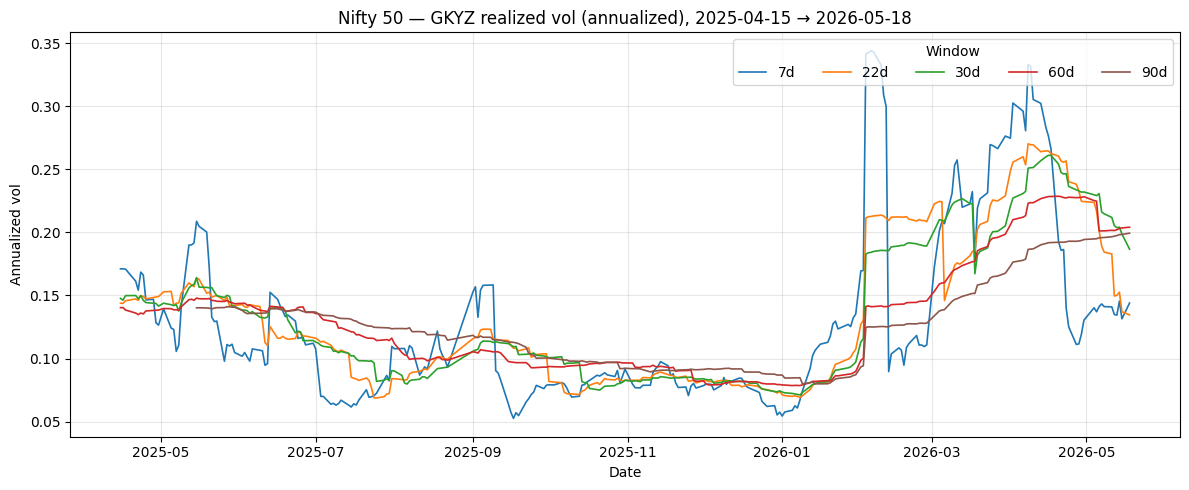

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 0.5, len(WINDOWS)))
for w, color in zip(WINDOWS, colors):
    col = f"gkyz_{w}d" if f"gkyz_{w}d" in gkyz_recent.columns else w
    s = gkyz_recent[col].dropna()
    ax.plot(s.index, s.values, linewidth=1.2, label=f"{w}d", color=color)

ax.set_title(
    f"Nifty 50 — GKYZ realized vol (annualized), {ohlcv.index.min().date()} → {ohlcv.index.max().date()}"
)
ax.set_ylabel("Annualized vol")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
ax.legend(title="Window", ncol=len(WINDOWS), loc="upper right")
plt.tight_layout()
plt.show()